In [1]:
!pip install datasets

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.



   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   --

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [7]:
from datasets import load_dataset

print("Downloading and loading UltraFeedback...")
dataset = load_dataset("openbmb/UltraFeedback", split="train")

print("\n--- Raw Data Example ---")
print(f"Prompt: {dataset[0]['instruction'][:100]}...")
print(f"Number of models that answered: {len(dataset[0]['completions'])}")


--- Raw Data Example ---
Prompt: Can you write a C++ program that prompts the user to enter the name of a country and checks if it bo...
Number of models that answered: 4


In [8]:
dataset

Dataset({
    features: ['source', 'instruction', 'models', 'completions', 'correct_answers', 'incorrect_answers'],
    num_rows: 63967
})

In [ ]:
def safe_float(val):
    try:
        return float(val) if val is not None else np.nan
    except (ValueError, TypeError):
        return np.nan

In [11]:
import tiktoken
tokenizer = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    if not text:
        return 0
    # encode_ordinary bypasses special token parsing checks
    return len(tokenizer.encode_ordinary(str(text)))

In [12]:
records = []
for row in dataset:
    prompt = row["instruction"]
    
    for completion in row["completions"]:
        model_name = completion.get("model")
        response = completion.get("response", "")
        annotations = completion.get("annotations", {})
        
        helpfulness = safe_float(annotations.get("helpfulness", {}).get("Rating"))
        honesty = safe_float(annotations.get("honesty", {}).get("Rating"))
        inst_follow = safe_float(annotations.get("instruction_following", {}).get("Rating"))
        truthfulness = safe_float(annotations.get("truthfulness", {}).get("Rating"))
        
        fine_grained = safe_float(completion.get("fine-grained_score"))
        overall = safe_float(completion.get("overall_score"))
        
        if np.isnan(overall) or np.isnan(fine_grained):
            continue
            
        token_count = count_tokens(response)
        
        records.append({
            "prompt": prompt,
            "model": model_name,
            "helpfulness": helpfulness,
            "honesty": honesty,
            "instruction_following": inst_follow,
            "truthfulness": truthfulness,
            "fine_grained_score": fine_grained,
            "overall_score": overall,
            "tokens": token_count,
            "log_tokens": np.log1p(token_count)
        })

df = pd.DataFrame(records)

sub_cols = ["helpfulness", "honesty", "instruction_following", "truthfulness"]
for col in sub_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
df.head(12)

,prompt,model,helpfulness,honesty,instruction_following,truthfulness,fine_grained_score,overall_score,tokens,log_tokens
0,Can you write a C++ program that prompts the u...,alpaca-7b,2.0,1.0,1.0,1.0,1.25,4.0,109,4.700480
1,Can you write a C++ program that prompts the u...,starchat,5.0,5.0,5.0,5.0,5.00,7.5,488,6.192362
2,Can you write a C++ program that prompts the u...,vicuna-33b,4.0,4.0,5.0,3.0,4.00,6.0,299,5.703782
3,Can you write a C++ program that prompts the u...,pythia-12b,1.0,1.0,2.0,1.0,1.25,3.0,216,5.379897
4,Suppose you are a content creator and want to ...,gpt-4,5.0,5.0,4.0,5.0,4.75,7.5,740,6.608001
5,Suppose you are a content creator and want to ...,llama-2-13b-chat,5.0,3.0,4.0,5.0,4.25,7.5,581,6.366470
6,Suppose you are a content creator and want to ...,starchat,3.0,4.0,3.0,3.0,3.25,7.5,327,5.793014
7,Suppose you are a content creator and want to ...,ultralm-65b,4.0,4.0,5.0,5.0,4.50,7.5,413,6.025866
8,"Identify the interrelated economic, political,...",mpt-30b-chat,4.0,4.0,4.0,5.0,4.25,7.0,671,6.510258
9,"Identify the interrelated economic, political,...",ultralm-13b,4.0,4.0,3.0,5.0,4.00,6.0,554,6.318968


In [20]:
dct = sorted(
    df['model'].value_counts().to_dict().items(),
    key=lambda x: x[1],
    reverse=True
)

print(dct)
print(len(dct))

[('wizardlm-13b', 16804), ('llama-2-7b-chat', 16773), ('vicuna-33b', 16753), ('ultralm-65b', 16681), ('llama-2-13b-chat', 16638), ('wizardlm-7b', 16596), ('ultralm-13b', 16583), ('llama-2-70b-chat', 16579), ('alpaca-7b', 16576), ('falcon-40b-instruct', 16568), ('gpt-3.5-turbo', 16561), ('mpt-30b-chat', 16561), ('wizardlm-70b', 16529), ('gpt-4', 16518), ('starchat', 13977), ('bard', 8333), ('pythia-12b', 834)]
17


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255864 entries, 0 to 255863
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   prompt                 255864 non-null  object 
 1   model                  255864 non-null  object 
 2   helpfulness            255864 non-null  float64
 3   honesty                255864 non-null  float64
 4   instruction_following  255864 non-null  float64
 5   truthfulness           255864 non-null  float64
 6   fine_grained_score     255864 non-null  float64
 7   overall_score          255864 non-null  float64
 8   tokens                 255864 non-null  int64  
 9   log_tokens             255864 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 19.5+ MB


In [27]:
df.describe()

,helpfulness,honesty,instruction_following,truthfulness,fine_grained_score,overall_score,tokens,log_tokens
count,255864.000000,255864.000000,255864.000000,255864.000000,255864.000000,255864.000000,255864.000000,255864.000000
mean,3.373202,3.908741,3.632414,3.988752,3.710314,6.439358,246.727625,4.885614
std,1.253410,1.306407,1.386533,1.305435,1.153624,1.977462,221.632698,1.394479
min,1.000000,1.000000,0.000000,1.000000,0.666667,1.000000,0.000000,0.000000
25%,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000,63.000000,4.158883
50%,4.000000,4.000000,4.000000,5.000000,4.000000,7.000000,183.000000,5.214936
75%,4.000000,5.000000,5.000000,5.000000,4.750000,8.000000,383.000000,5.950643
max,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,1995.000000,7.598900


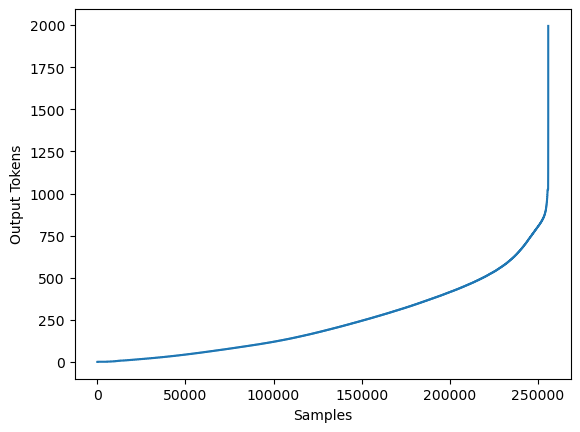

In [28]:
plt.plot(df['tokens'].sort_values().reset_index(drop=True))
plt.xlabel("Samples")
plt.ylabel("Output Tokens")
plt.show()

In [31]:
# Drop the underrepresented and proprietary models
models_to_drop = ['bard', 'pythia-12b']
df = df[~df['model'].isin(models_to_drop)].copy()

active_models = df['model'].unique().tolist()
print(f"Remaining candidate LLMs: {len(active_models)}")

Remaining candidate LLMs: 15


In [32]:
df.head()

,prompt,model,helpfulness,honesty,instruction_following,truthfulness,fine_grained_score,overall_score,tokens,log_tokens
0,Can you write a C++ program that prompts the u...,alpaca-7b,2.0,1.0,1.0,1.0,1.25,4.0,109,4.700480
1,Can you write a C++ program that prompts the u...,starchat,5.0,5.0,5.0,5.0,5.00,7.5,488,6.192362
2,Can you write a C++ program that prompts the u...,vicuna-33b,4.0,4.0,5.0,3.0,4.00,6.0,299,5.703782
4,Suppose you are a content creator and want to ...,gpt-4,5.0,5.0,4.0,5.0,4.75,7.5,740,6.608001
5,Suppose you are a content creator and want to ...,llama-2-13b-chat,5.0,3.0,4.0,5.0,4.25,7.5,581,6.366470


In [35]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

unique_prompts = df['prompt'].unique().tolist()

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device='cpu')

print(f"Embedding {len(unique_prompts)} prompts...")
embeddings_matrix = embedder.encode(
    unique_prompts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True 
)

prompt_to_idx = {prompt: idx for idx, prompt in enumerate(unique_prompts)}

df['prompt_idx'] = df['prompt'].map(prompt_to_idx)

np.save("ultrafeedback_prompt_embeddings.npy", embeddings_matrix)

print("Mapping complete. DataFrame is ready for model-specific splitting.")
print(df[['prompt_idx', 'model']].head())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding 63936 prompts...


Batches:   0%|          | 0/250 [00:00<?, ?it/s]

Mapping complete. DataFrame is ready for model-specific splitting.
   prompt_idx             model
0           0         alpaca-7b
1           0          starchat
2           0        vicuna-33b
4           1             gpt-4
5           1  llama-2-13b-chat


In [36]:
df.head()

,prompt,model,helpfulness,honesty,instruction_following,truthfulness,fine_grained_score,overall_score,tokens,log_tokens,prompt_idx
0,Can you write a C++ program that prompts the u...,alpaca-7b,2.0,1.0,1.0,1.0,1.25,4.0,109,4.700480,0
1,Can you write a C++ program that prompts the u...,starchat,5.0,5.0,5.0,5.0,5.00,7.5,488,6.192362,0
2,Can you write a C++ program that prompts the u...,vicuna-33b,4.0,4.0,5.0,3.0,4.00,6.0,299,5.703782,0
4,Suppose you are a content creator and want to ...,gpt-4,5.0,5.0,4.0,5.0,4.75,7.5,740,6.608001,1
5,Suppose you are a content creator and want to ...,llama-2-13b-chat,5.0,3.0,4.0,5.0,4.25,7.5,581,6.366470,1


In [38]:
model_counts = df['model'].value_counts()
print(model_counts)

model
wizardlm-13b           16804
llama-2-7b-chat        16773
vicuna-33b             16753
ultralm-65b            16681
llama-2-13b-chat       16638
wizardlm-7b            16596
ultralm-13b            16583
llama-2-70b-chat       16579
alpaca-7b              16576
falcon-40b-instruct    16568
mpt-30b-chat           16561
gpt-3.5-turbo          16561
wizardlm-70b           16529
gpt-4                  16518
starchat               13977
Name: count, dtype: int64


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


os.makedirs("evaluator_weights", exist_ok=True)
os.makedirs("training_plots", exist_ok=True)

tf.keras.utils.set_random_seed(42)

BATCH_SIZE = 128
EPOCHS = 100

DROP_MODELS = {"bard", "pythia-12b"}

active_models = [
    m for m in df["model"].unique()
    if m not in DROP_MODELS
]

print(f"Training {len(active_models)} models:")
print(active_models)

TARGET_COLS = [
    "helpfulness",
    "honesty",
    "instruction_following",
    "truthfulness",
    "fine_grained_score",
    "overall_score",
    "log_tokens"
]

tf_embeddings = tf.constant(
    embeddings_matrix,
    dtype=tf.float32
)

def build_tf_dataset(df_subset, shuffle=False, batch_size=128):

    target_dict = {
        col: df_subset[col].to_numpy(
            dtype=np.float32
        ).reshape(-1, 1)
        for col in TARGET_COLS
    }

    prompt_indices = df_subset["prompt_idx"].to_numpy(
        dtype=np.int32
    )

    ds = tf.data.Dataset.from_tensor_slices(
        (
            prompt_indices,
            target_dict
        )
    )

    def resolve_features(prompt_idx, targets):
        embedding = tf.gather(
            tf_embeddings,
            prompt_idx
        )

        return {
            "prompt_emb": embedding
        }, targets

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(df_subset), 20000),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = (
        ds
        .batch(batch_size)
        .map(
            resolve_features,
            num_parallel_calls=tf.data.AUTOTUNE
        )
        .prefetch(tf.data.AUTOTUNE)
    )

    return ds

def build_evaluator_model(
    embedding_dim=384,
    hidden_dim=128
):

    inputs = tf.keras.Input(
        shape=(embedding_dim,),
        name="prompt_emb"
    )

    # First layer
    x = tf.keras.layers.Dense(
        hidden_dim,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(inputs)

    x = tf.keras.layers.Dropout(0.30)(x)

    # Second layer
    x = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    )(x)

    x = tf.keras.layers.Dropout(0.20)(x)

    # Output heads
    outputs = {
        "helpfulness": tf.keras.layers.Dense(
            1,
            name="helpfulness"
        )(x),

        "honesty": tf.keras.layers.Dense(
            1,
            name="honesty"
        )(x),

        "instruction_following": tf.keras.layers.Dense(
            1,
            name="instruction_following"
        )(x),

        "truthfulness": tf.keras.layers.Dense(
            1,
            name="truthfulness"
        )(x),

        "fine_grained_score": tf.keras.layers.Dense(
            1,
            name="fine_grained_score"
        )(x),

        "overall_score": tf.keras.layers.Dense(
            1,
            name="overall_score"
        )(x),

        "log_tokens": tf.keras.layers.Dense(
            1,
            name="log_tokens"
        )(x)
    }

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )


    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=3e-4
        ),

        loss={
            "helpfulness": "mse",
            "honesty": "mse",
            "instruction_following": "mse",
            "truthfulness": "mse",
            "fine_grained_score": "mse",
            "overall_score": "mse",
            "log_tokens": tf.keras.losses.Huber()
        }
    )

    return model



for llm_name in active_models:

    print("\n" + "=" * 60)
    print(f"Training evaluator for: {llm_name}")
    print("=" * 60)

    df_llm = df[
        df["model"] == llm_name
    ].sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)

    print(f"Total samples: {len(df_llm)}")

    split_idx = int(len(df_llm) * 0.90)

    df_train = df_llm.iloc[:split_idx].copy()
    df_val = df_llm.iloc[split_idx:].copy()

    print(f"Train samples: {len(df_train)}")
    print(f"Validation samples: {len(df_val)}")

    train_ds = build_tf_dataset(
        df_train,
        shuffle=True,
        batch_size=BATCH_SIZE
    )

    val_ds = build_tf_dataset(
        df_val,
        shuffle=False,
        batch_size=BATCH_SIZE
    )

    evaluator = build_evaluator_model()

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_overall_score_loss",
        patience=8,
        mode="min",
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_overall_score_loss",
        factor=0.5,
        patience=3,
        mode="min",
        min_lr=1e-6,
        verbose=1
    )

    history = evaluator.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[
            early_stopping,
            reduce_lr
        ],
        verbose=1
    )

    safe_name = (
        llm_name
        .replace("/", "_")
        .replace("-", "_")
    )

    weight_path = (
        f"evaluator_weights/"
        f"{safe_name}.weights.h5"
    )

    evaluator.save_weights(weight_path)

    print(f"Saved weights → {weight_path}")


    plt.figure(figsize=(16, 5))


    plt.subplot(1, 3, 1)

    plt.plot(
        history.history["overall_score_loss"],
        label="Train"
    )

    plt.plot(
        history.history["val_overall_score_loss"],
        label="Validation"
    )

    plt.title(
        f"{llm_name} - Overall Score Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()

    plt.subplot(1, 3, 2)

    plt.plot(
        history.history["fine_grained_score_loss"],
        label="Train"
    )

    plt.plot(
        history.history["val_fine_grained_score_loss"],
        label="Validation"
    )

    plt.title(
        f"{llm_name} - Fine Grained Score Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()

    plt.subplot(1, 3, 3)

    plt.plot(
        history.history["log_tokens_loss"],
        label="Train"
    )

    plt.plot(
        history.history["val_log_tokens_loss"],
        label="Validation"
    )

    plt.title(
        f"{llm_name} - Token Prediction Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Huber Loss")
    plt.legend()

    plt.tight_layout()

    plot_path = (
        f"training_plots/"
        f"{safe_name}_history.png"
    )

    plt.savefig(
        plot_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved plot → {plot_path}")

Training 15 models:
['alpaca-7b', 'starchat', 'vicuna-33b', 'gpt-4', 'llama-2-13b-chat', 'ultralm-65b', 'mpt-30b-chat', 'ultralm-13b', 'wizardlm-7b', 'wizardlm-13b', 'falcon-40b-instruct', 'llama-2-70b-chat', 'llama-2-7b-chat', 'wizardlm-70b', 'gpt-3.5-turbo']

Training evaluator for: alpaca-7b
Total samples: 16576
Train samples: 14918
Validation samples: 1658
Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - fine_grained_score_loss: 7.1142 - helpfulness_loss: 5.9027 - honesty_loss: 6.5462 - instruction_following_loss: 6.2618 - log_tokens_loss: 2.9735 - loss: 60.9068 - overall_score_loss: 24.1755 - truthfulness_loss: 7.7802 - val_fine_grained_score_loss: 2.4063 - val_helpfulness_loss: 2.4518 - val_honesty_loss: 3.0060 - val_instruction_following_loss: 2.4591 - val_log_tokens_loss: 2.1011 - val_loss: 25.1731 - val_overall_score_loss: 9.7148 - val_truthfulness_loss: 3.0000 - learning_rate: 3.0000e-04
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - fine_grained_score_loss: 1.9